In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix,accuracy_score, roc_curve, auc
from sklearn.metrics import recall_score,precision_score
from sklearn.neighbors import KNeighborsClassifier
sns.set_style("whitegrid")
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Raw Data Prediction **

In [ ]:
df_benchmark = pd.read_csv('/content/drive/MyDrive/ikea.csv')

In [ ]:
df_benchmark.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3694 entries, 0 to 3693
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3694 non-null   int64  
 1   item_id            3694 non-null   int64  
 2   name               3694 non-null   object 
 3   category           3694 non-null   object 
 4   price              3694 non-null   float64
 5   old_price          3694 non-null   object 
 6   sellable_online    3694 non-null   bool   
 7   link               3694 non-null   object 
 8   other_colors       3694 non-null   object 
 9   short_description  3694 non-null   object 
 10  designer           3694 non-null   object 
 11  depth              2231 non-null   float64
 12  height             2706 non-null   float64
 13  width              3105 non-null   float64
dtypes: bool(1), float64(4), int64(2), object(7)
memory usage: 378.9+ KB


In [ ]:
df_benchmark.sum()

,0
Unnamed: 0,6820971
item_id,179648073742
name,FREKVENSNORDVIKENNORDVIKEN / NORDVIKENSTIGNORB...
category,Bar furnitureBar furnitureBar furnitureBar fur...
price,3982901.9
old_price,No old priceNo old priceNo old priceNo old pri...
sellable_online,3666
link,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...
other_colors,NoNoNoYesNoNoNoNoNoNoNoNoNoNoNoNoNoYesNoNoNoNo...
short_description,"Bar table, in/outdoor, 51x51 ..."


In [ ]:
# Create a copy of the dataframe to avoid modifying the original
benchmark_head = df_benchmark.copy()

# Remove specific columns from the copy
benchmark_head = benchmark_head.drop(['old_price','item_id', 'name', 'link', 'short_description'], axis=1)

# If you need to do something with the modified data, use benchmark_head.
# For example, you could display the first few rows:
benchmark_head.head(3)

,Unnamed: 0,category,price,sellable_online,other_colors,designer,depth,height,width
0,0,Bar furniture,265.0,True,No,Nicholai Wiig Hansen,NaN,99.0,51.0
1,1,Bar furniture,995.0,False,No,Francis Cayouette,NaN,105.0,80.0
2,2,Bar furniture,2095.0,False,No,Francis Cayouette,NaN,NaN,NaN


In [ ]:
import pandas as pd

# Convert all columns in benchmark_head to dummy variables
benchmark_head_dummies = pd.get_dummies(benchmark_head, drop_first=True, dtype=int)

# Display the converted DataFrame
benchmark_head_dummies.head()

,Unnamed: 0,price,sellable_online,depth,height,width,category_Beds,category_Bookcases & shelving units,category_Cabinets & cupboards,category_Café furniture,...,designer_T Winkel/T Jacobsen,designer_Thomas Sandell,designer_Tina Christensen,designer_Tina Christensen/Jomi Evers,designer_Tom Dixon,designer_Tom Dixon/IKEA of Sweden,designer_Tord Björklund,designer_Tord Björklund/IKEA of Sweden,designer_Virgil Abloh,designer_Wiebke Braasch
0,0,265.0,True,NaN,99.0,51.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,995.0,False,NaN,105.0,80.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,2095.0,False,NaN,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,69.0,True,50.0,100.0,60.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,225.0,True,60.0,43.0,74.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import pandas as pd

# Calculate the median of the price column
price_median = benchmark_head_dummies['price'].median()
print(price_median)

# Create a new column 'price_category' with 1 for 'High' and 0 for 'Low'
benchmark_head_dummies['price_category_high'] = benchmark_head_dummies['price'].apply(lambda x: 1 if x > price_median else 0)

benchmark_head_dummies.head(3)

544.7


,Unnamed: 0,price,sellable_online,depth,height,width,category_Beds,category_Bookcases & shelving units,category_Cabinets & cupboards,category_Café furniture,...,designer_Thomas Sandell,designer_Tina Christensen,designer_Tina Christensen/Jomi Evers,designer_Tom Dixon,designer_Tom Dixon/IKEA of Sweden,designer_Tord Björklund,designer_Tord Björklund/IKEA of Sweden,designer_Virgil Abloh,designer_Wiebke Braasch,price_category_high
0,0,265.0,True,NaN,99.0,51.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,995.0,False,NaN,105.0,80.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,2,2095.0,False,NaN,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:

benchmark_head_dummies.head(3)

,Unnamed: 0,price,sellable_online,depth,height,width,category_Beds,category_Bookcases & shelving units,category_Cabinets & cupboards,category_Café furniture,...,designer_Thomas Sandell,designer_Tina Christensen,designer_Tina Christensen/Jomi Evers,designer_Tom Dixon,designer_Tom Dixon/IKEA of Sweden,designer_Tord Björklund,designer_Tord Björklund/IKEA of Sweden,designer_Virgil Abloh,designer_Wiebke Braasch,price_category_high
0,0,265.0,True,NaN,99.0,51.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,995.0,False,NaN,105.0,80.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,2,2095.0,False,NaN,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
benchmark_head_dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3694 entries, 0 to 3693
Columns: 404 entries, Unnamed: 0 to price_category_high
dtypes: bool(1), float64(4), int64(399)
memory usage: 11.4 MB


In [ ]:
# Replace NaN and inf/-inf values with 0
benchmark_head_dummies = benchmark_head_dummies.replace([np.inf, -np.inf], 0)  # Replace inf values with 0
benchmark_head_dummies = benchmark_head_dummies.fillna(0)  # Replace NaN values with 0

# Convert all values to integers
benchmark_head_dummies = benchmark_head_dummies.astype(int)

# Display the updated DataFrame
benchmark_head_dummies.head(3)

,Unnamed: 0,price,sellable_online,depth,height,width,category_Beds,category_Bookcases & shelving units,category_Cabinets & cupboards,category_Café furniture,...,designer_Thomas Sandell,designer_Tina Christensen,designer_Tina Christensen/Jomi Evers,designer_Tom Dixon,designer_Tom Dixon/IKEA of Sweden,designer_Tord Björklund,designer_Tord Björklund/IKEA of Sweden,designer_Virgil Abloh,designer_Wiebke Braasch,price_category_high
0,0,265,1,0,99,51,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,995,0,0,105,80,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,2,2095,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# prompt: benchmark_head_dummies drop price

# Drop the 'price' column
benchmark_head_dummies = benchmark_head_dummies.drop(['price'], axis=1)

benchmark_head_dummies.head(3)

,Unnamed: 0,sellable_online,depth,height,width,category_Beds,category_Bookcases & shelving units,category_Cabinets & cupboards,category_Café furniture,category_Chairs,...,designer_Thomas Sandell,designer_Tina Christensen,designer_Tina Christensen/Jomi Evers,designer_Tom Dixon,designer_Tom Dixon/IKEA of Sweden,designer_Tord Björklund,designer_Tord Björklund/IKEA of Sweden,designer_Virgil Abloh,designer_Wiebke Braasch,price_category_high
0,0,1,0,99,51,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,105,80,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
benchmark_head_dummies = benchmark_head_dummies.drop(['Unnamed: 0'], axis=1)

benchmark_head_dummies.head(3)

,sellable_online,depth,height,width,category_Beds,category_Bookcases & shelving units,category_Cabinets & cupboards,category_Café furniture,category_Chairs,category_Chests of drawers & drawer units,...,designer_Thomas Sandell,designer_Tina Christensen,designer_Tina Christensen/Jomi Evers,designer_Tom Dixon,designer_Tom Dixon/IKEA of Sweden,designer_Tord Björklund,designer_Tord Björklund/IKEA of Sweden,designer_Virgil Abloh,designer_Wiebke Braasch,price_category_high
0,1,0,99,51,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,105,80,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
benchmark_head_dummies = benchmark_head_dummies.astype(int)
benchmark_head_dummies.head(3)

,sellable_online,depth,height,width,category_Beds,category_Bookcases & shelving units,category_Cabinets & cupboards,category_Café furniture,category_Chairs,category_Chests of drawers & drawer units,...,designer_Thomas Sandell,designer_Tina Christensen,designer_Tina Christensen/Jomi Evers,designer_Tom Dixon,designer_Tom Dixon/IKEA of Sweden,designer_Tord Björklund,designer_Tord Björklund/IKEA of Sweden,designer_Virgil Abloh,designer_Wiebke Braasch,price_category_high
0,1,0,99,51,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,105,80,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
benchmark_head_dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3694 entries, 0 to 3693
Columns: 400 entries, Unnamed: 0 to price_category_high
dtypes: int64(400)
memory usage: 11.3 MB


In [ ]:
benchmark_head_dummies.sum()

,0
sellable_online,3666
depth,121320
height,275146
width,324382
category_Beds,208
...,...
designer_Tord Björklund,31
designer_Tord Björklund/IKEA of Sweden,12
designer_Virgil Abloh,5
designer_Wiebke Braasch,2


We did not categorize furniture into storage furniture we used all different types of furniture such as bed, chair, lamp, outdoor, children's etc. We did not drop missing values, we did not calculate dimensions and categorize it by small medium and large. We did not drop any of columns (kept all of them such as 'item_id', 'name', 'link', 'short_description'). The only thing we did was set price to high and low by median value to create our target variable (high price) = 1 else 0. so we had to drop the price. We had to replace NaN and Inf values with 0 because our program would not run.

### *Decision Tree (Base) without categorizing data *

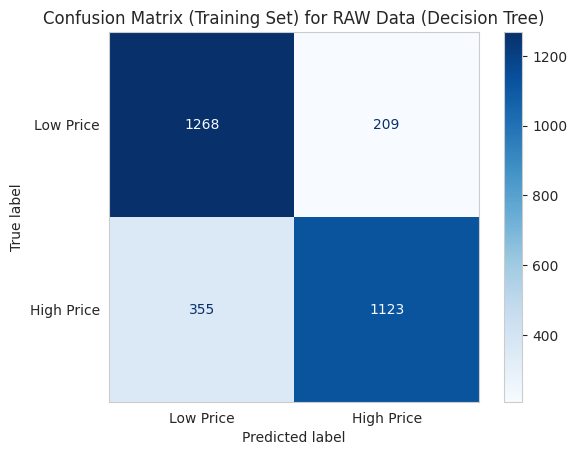

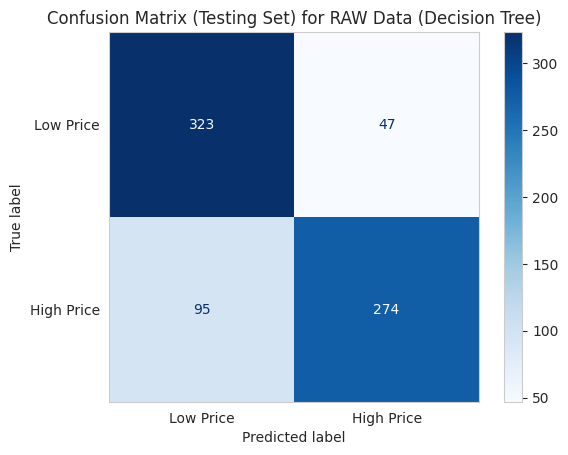

Training Accuracy: 0.8091370558375635
Testing Accuracy: 0.8078484438430311

Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.78      0.86      0.82      1477
           1       0.84      0.76      0.80      1478

    accuracy                           0.81      2955
   macro avg       0.81      0.81      0.81      2955
weighted avg       0.81      0.81      0.81      2955


Classification Report (Testing Set):
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       370
           1       0.85      0.74      0.79       369

    accuracy                           0.81       739
   macro avg       0.81      0.81      0.81       739
weighted avg       0.81      0.81      0.81       739



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Step 1: Define Features (X) and Target (y)
X = benchmark_head_dummies.drop(columns=['price_category_high'])  # Features
y = benchmark_head_dummies['price_category_high']  # Target variable

# Step 2: Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # Stratify to maintain class distribution
)
# Step 3: Train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Step 4: Make Predictions for Training and Testing Sets
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Step 5: Confusion Matrix for Training Set
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix_train,
    display_labels=['Low Price', 'High Price']  # Replace with your class labels
)
disp_train.plot(cmap='Blues', values_format='d')
plt.grid(False)  # Disable gridlines
plt.title("Confusion Matrix (Training Set) for RAW Data (Decision Tree)")
plt.show()

# Step 6: Confusion Matrix for Testing Set
conf_matrix_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix_test,
    display_labels=['Low Price', 'High Price']  # Replace with your class labels
)
disp_test.plot(cmap='Blues', values_format='d')
plt.grid(False)  # Disable gridlines
plt.title("Confusion Matrix (Testing Set) for RAW Data (Decision Tree)")
plt.show()

# Step 7: Model Performance Metrics
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report (Training Set):")
print(classification_report(y_train, y_train_pred))

print("\nClassification Report (Testing Set):")
print(classification_report(y_test, y_test_pred))

### **Random Forest Without Pre Processing Data **

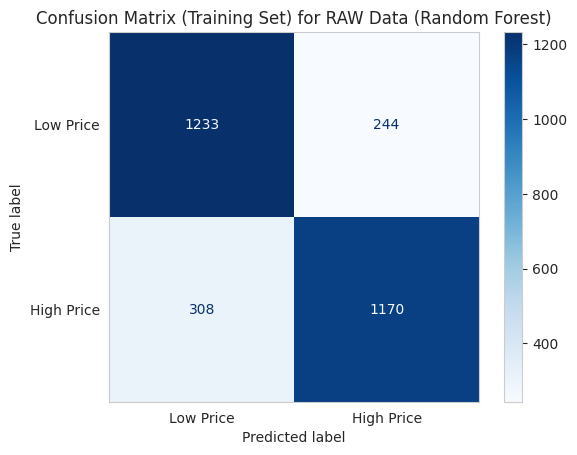

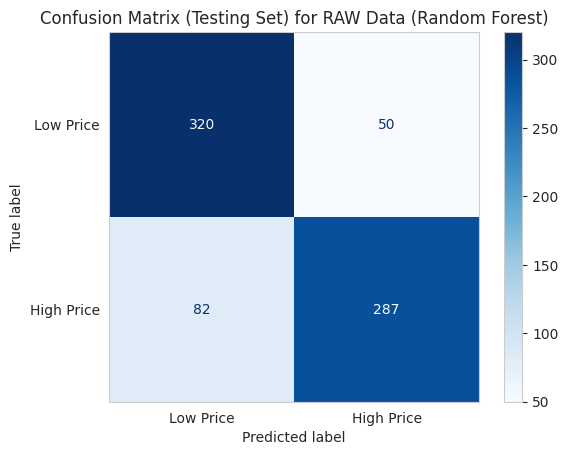

Training Accuracy: 0.8131979695431472
Testing Accuracy: 0.8213802435723951

Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.80      0.83      0.82      1477
           1       0.83      0.79      0.81      1478

    accuracy                           0.81      2955
   macro avg       0.81      0.81      0.81      2955
weighted avg       0.81      0.81      0.81      2955


Classification Report (Testing Set):
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       370
           1       0.85      0.78      0.81       369

    accuracy                           0.82       739
   macro avg       0.82      0.82      0.82       739
weighted avg       0.82      0.82      0.82       739



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Step 1: Define Features (X) and Target (y)
X = benchmark_head_dummies.drop(columns=['price_category_high'])  # Features
y = benchmark_head_dummies['price_category_high']  # Target variable

# Step 2: Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # Stratify to maintain class distribution
)

# Step 3: Train the Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,  # Number of trees
    max_depth=5,       # Maximum depth of the tree
    criterion='entropy',  # Criterion for splitting
    random_state=42    # Ensures reproducibility
)
rf_model.fit(X_train, y_train)

# Step 4: Make Predictions for Training and Testing Sets
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Step 5: Confusion Matrix for Training Set
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix_train,
    display_labels=['Low Price', 'High Price']
)
disp_train.plot(cmap='Blues', values_format='d')
plt.grid(False)  # Disable gridlines
plt.title("Confusion Matrix (Training Set) for RAW Data (Random Forest)")
plt.show()

# Step 6: Confusion Matrix for Testing Set
conf_matrix_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix_test,
    display_labels=['Low Price', 'High Price']
)
disp_test.plot(cmap='Blues', values_format='d')
plt.grid(False)  # Disable gridlines
plt.title("Confusion Matrix (Testing Set) for RAW Data (Random Forest)")
plt.show()

# Step 7: Model Performance Metrics
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report (Training Set):")
print(classification_report(y_train, y_train_pred))

print("\nClassification Report (Testing Set):")
print(classification_report(y_test, y_test_pred))

### **XGBoost Raw Data Processing**

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [18:13:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


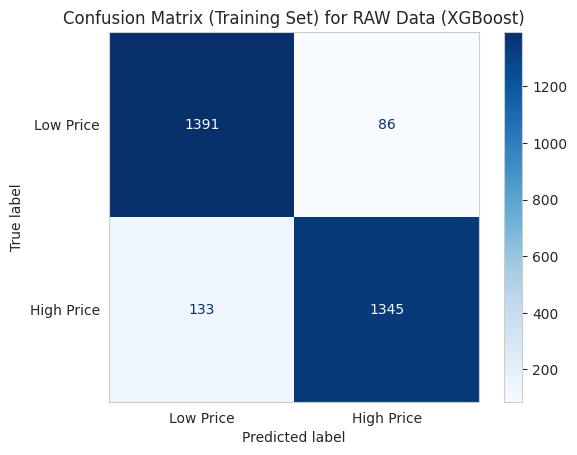

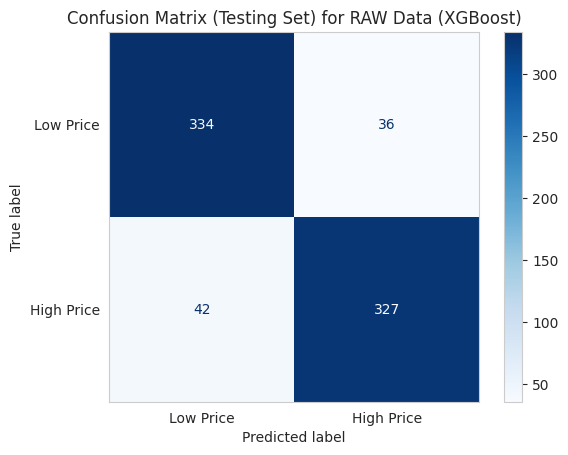

Training Accuracy: 0.9258883248730965
Testing Accuracy: 0.8944519621109608

Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1477
           1       0.94      0.91      0.92      1478

    accuracy                           0.93      2955
   macro avg       0.93      0.93      0.93      2955
weighted avg       0.93      0.93      0.93      2955


Classification Report (Testing Set):
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       370
           1       0.90      0.89      0.89       369

    accuracy                           0.89       739
   macro avg       0.89      0.89      0.89       739
weighted avg       0.89      0.89      0.89       739



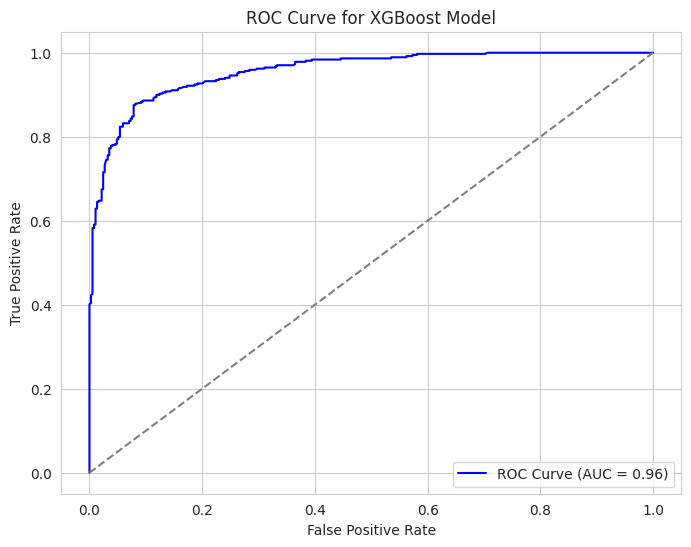

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Step 1: Define Features (X) and Target (y)
X = benchmark_head_dummies.drop(columns=['price_category_high'])  # Features
y = benchmark_head_dummies['price_category_high']  # Target variable

# Step 2: Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # Stratify to maintain class distribution
)

# Step 3: Train the XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=100,  # Number of trees
    max_depth=5,       # Maximum depth of the tree
    learning_rate=0.1,  # Learning rate for boosting
    random_state=42,
    use_label_encoder=False,  # Suppresses warning in newer versions
    eval_metric='logloss'     # Evaluation metric for classification
)
xgb_model.fit(X_train, y_train)

# Step 4: Make Predictions for Training and Testing Sets
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)
y_test_prob = xgb_model.predict_proba(X_test)[:, 1]  # Predicted probabilities for ROC curve

# Step 5: Confusion Matrix for Training Set
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix_train,
    display_labels=['Low Price', 'High Price']
)
disp_train.plot(cmap='Blues', values_format='d')
plt.grid(False)  # Disable gridlines
plt.title("Confusion Matrix (Training Set) for RAW Data (XGBoost)")
plt.show()

# Step 6: Confusion Matrix for Testing Set
conf_matrix_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix_test,
    display_labels=['Low Price', 'High Price']
)
disp_test.plot(cmap='Blues', values_format='d')
plt.grid(False)  # Disable gridlines
plt.title("Confusion Matrix (Testing Set) for RAW Data (XGBoost)")
plt.show()

# Step 7: Model Performance Metrics
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report (Training Set):")
print(classification_report(y_train, y_train_pred))

print("\nClassification Report (Testing Set):")
print(classification_report(y_test, y_test_pred))

# Step 8: Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)  # Calculate FPR and TPR
roc_auc = auc(fpr, tpr)  # Calculate AUC

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.title("ROC Curve for XGBoost Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# **Pre Procesing **

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ikea.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3694 entries, 0 to 3693
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3694 non-null   int64  
 1   item_id            3694 non-null   int64  
 2   name               3694 non-null   object 
 3   category           3694 non-null   object 
 4   price              3694 non-null   float64
 5   old_price          3694 non-null   object 
 6   sellable_online    3694 non-null   bool   
 7   link               3694 non-null   object 
 8   other_colors       3694 non-null   object 
 9   short_description  3694 non-null   object 
 10  designer           3694 non-null   object 
 11  depth              2231 non-null   float64
 12  height             2706 non-null   float64
 13  width              3105 non-null   float64
dtypes: bool(1), float64(4), int64(2), object(7)
memory usage: 378.9+ KB


In [ ]:


df.isnull().sum()

,0
Unnamed: 0,0
item_id,0
name,0
category,0
price,0
old_price,0
sellable_online,0
link,0
other_colors,0
short_description,0


In [ ]:
 #drop missing values

df.dropna(inplace=True)

In [ ]:
df.info()
df.sum()

<class 'pandas.core.frame.DataFrame'>
Index: 1899 entries, 3 to 3688
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1899 non-null   int64  
 1   item_id            1899 non-null   int64  
 2   name               1899 non-null   object 
 3   category           1899 non-null   object 
 4   price              1899 non-null   float64
 5   old_price          1899 non-null   object 
 6   sellable_online    1899 non-null   bool   
 7   link               1899 non-null   object 
 8   other_colors       1899 non-null   object 
 9   short_description  1899 non-null   object 
 10  designer           1899 non-null   object 
 11  depth              1899 non-null   float64
 12  height             1899 non-null   float64
 13  width              1899 non-null   float64
dtypes: bool(1), float64(4), int64(2), object(7)
memory usage: 209.6+ KB


,0
Unnamed: 0,3251958
item_id,92681045704
name,STIGNORBERGINGOLFFRANKLINFRANKLINFRANKLININGOL...
category,Bar furnitureBar furnitureBar furnitureBar fur...
price,2317970.6
old_price,No old priceNo old priceNo old priceNo old pri...
sellable_online,1886
link,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...
other_colors,YesNoNoNoNoNoNoNoNoNoNoNoNoNoNoNoNoNoNoYesNoNo...
short_description,"Bar stool with backrest, 74 c..."


In [ ]:
#drop item_id,name,link,short_description

df = df.drop(['item_id', 'name', 'link', 'short_description'], axis=1)

df.head(10)

,Unnamed: 0,category,price,old_price,sellable_online,other_colors,designer,depth,height,width
3,3,Bar furniture,69.0,No old price,True,Yes,Henrik Preutz,50.0,100.0,60.0
4,4,Bar furniture,225.0,No old price,True,No,Marcus Arvonen,60.0,43.0,74.0
5,5,Bar furniture,345.0,No old price,True,No,Carina Bengs,45.0,91.0,40.0
6,6,Bar furniture,129.0,No old price,True,No,K Hagberg/M Hagberg,44.0,95.0,50.0
8,8,Bar furniture,129.0,No old price,True,No,K Hagberg/M Hagberg,44.0,95.0,50.0
10,10,Bar furniture,149.0,No old price,True,No,K Hagberg/M Hagberg,44.0,103.0,52.0
11,11,Bar furniture,395.0,No old price,True,No,Carina Bengs,45.0,102.0,40.0
12,12,Bar furniture,395.0,No old price,True,No,Nike Karlsson,47.0,103.0,46.0
13,13,Bar furniture,177.0,SR 295,True,No,Nicholai Wiig Hansen,53.0,104.0,43.0
14,14,Bar furniture,345.0,No old price,True,No,Ehlén Johansson,52.0,114.0,43.0


We will only look at one main type of furniture : Storage furniture, for this we will categorize the types of futniture that we believe will fall into storage furniture

In [ ]:
# Cabinets & cupboards, Chest of drawers, Wardrobes Bookcases & shelving units

# Create the df_storagefurniture DataFrame
categories_to_include = ['Bookcases & shelving units', 'Cabinets & cupboards', 'Chest of drawers', 'Wardrobes']
df_storagefurniture = df[df['category'].isin(categories_to_include)]
df_storagefurniture.head(10)

,Unnamed: 0,category,price,old_price,sellable_online,other_colors,designer,depth,height,width
255,255,Bookcases & shelving units,135.0,SR 138,True,No,IKEA of Sweden,51.0,70.0,25.0
256,256,Bookcases & shelving units,290.0,SR 350,True,No,IKEA of Sweden,36.0,181.0,92.0
257,257,Bookcases & shelving units,915.0,"SR 1,023",True,No,IKEA of Sweden,51.0,173.0,198.0
258,258,Bookcases & shelving units,345.0,No old price,True,No,IKEA of Sweden,35.0,81.0,80.0
259,259,Bookcases & shelving units,375.0,SR 437,True,No,IKEA of Sweden,51.0,160.0,182.0
261,261,Bookcases & shelving units,95.0,No old price,True,No,IKEA of Sweden,24.0,180.0,60.0
262,262,Bookcases & shelving units,115.0,No old price,True,Yes,Tord Björklund,39.0,77.0,77.0
263,263,Bookcases & shelving units,199.0,No old price,True,Yes,C Halskov/H Dalsgaard,28.0,190.0,30.0
264,264,Bookcases & shelving units,59.0,No old price,True,No,IKEA of Sweden,27.0,140.0,60.0
265,265,Bookcases & shelving units,250.0,No old price,True,Yes,Tord Björklund,39.0,147.0,77.0


Convert price to split high/low using median so that data is evenly split

In [ ]:
import pandas as pd

# Calculate the median of the price column
price_median = df_storagefurniture['price'].median()
print(price_median)

# Create a new column 'price_category' with 1 for 'High' and 0 for 'Low'
df_storagefurniture['price_category_high'] = df_storagefurniture['price'].apply(lambda x: 1 if x > price_median else 0)

df_storagefurniture.head(20)

795.0


<ipython-input-28-39e7ad8da47e>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_storagefurniture['price_category_high'] = df_storagefurniture['price'].apply(lambda x: 1 if x > price_median else 0)


,Unnamed: 0,category,price,old_price,sellable_online,other_colors,designer,depth,height,width,price_category_high
255,255,Bookcases & shelving units,135.0,SR 138,True,No,IKEA of Sweden,51.0,70.0,25.0,0
256,256,Bookcases & shelving units,290.0,SR 350,True,No,IKEA of Sweden,36.0,181.0,92.0,0
257,257,Bookcases & shelving units,915.0,"SR 1,023",True,No,IKEA of Sweden,51.0,173.0,198.0,1
258,258,Bookcases & shelving units,345.0,No old price,True,No,IKEA of Sweden,35.0,81.0,80.0,0
259,259,Bookcases & shelving units,375.0,SR 437,True,No,IKEA of Sweden,51.0,160.0,182.0,0
261,261,Bookcases & shelving units,95.0,No old price,True,No,IKEA of Sweden,24.0,180.0,60.0,0
262,262,Bookcases & shelving units,115.0,No old price,True,Yes,Tord Björklund,39.0,77.0,77.0,0
263,263,Bookcases & shelving units,199.0,No old price,True,Yes,C Halskov/H Dalsgaard,28.0,190.0,30.0,0
264,264,Bookcases & shelving units,59.0,No old price,True,No,IKEA of Sweden,27.0,140.0,60.0,0
265,265,Bookcases & shelving units,250.0,No old price,True,Yes,Tord Björklund,39.0,147.0,77.0,0


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np

# Ensure df_storagefurniture is a copy to avoid SettingWithCopyWarning
df_storagefurniture = df_storagefurniture.copy()

# Check if 'depth', 'height', and 'width' columns exist
required_columns = {'depth', 'height', 'width'}
if required_columns.issubset(df_storagefurniture.columns):
    # Safely create a new column named 'Volume (Size)' by multiplying depth, height, and width
    df_storagefurniture['volume'] = (
        df_storagefurniture['depth'] *
        df_storagefurniture['height'] *
        df_storagefurniture['width']
    )
    print("Dimensions column created successfully.")
else:
    print(f"Error: Missing columns. Ensure {required_columns} are in the DataFrame.")

Dimensions column created successfully.


In [ ]:
df_storagefurniture.head(10)

,Unnamed: 0,category,price,old_price,sellable_online,other_colors,designer,depth,height,width,price_category_high,volume
255,255,Bookcases & shelving units,135.0,SR 138,True,No,IKEA of Sweden,51.0,70.0,25.0,0,89250.0
256,256,Bookcases & shelving units,290.0,SR 350,True,No,IKEA of Sweden,36.0,181.0,92.0,0,599472.0
257,257,Bookcases & shelving units,915.0,"SR 1,023",True,No,IKEA of Sweden,51.0,173.0,198.0,1,1746954.0
258,258,Bookcases & shelving units,345.0,No old price,True,No,IKEA of Sweden,35.0,81.0,80.0,0,226800.0
259,259,Bookcases & shelving units,375.0,SR 437,True,No,IKEA of Sweden,51.0,160.0,182.0,0,1485120.0
261,261,Bookcases & shelving units,95.0,No old price,True,No,IKEA of Sweden,24.0,180.0,60.0,0,259200.0
262,262,Bookcases & shelving units,115.0,No old price,True,Yes,Tord Björklund,39.0,77.0,77.0,0,231231.0
263,263,Bookcases & shelving units,199.0,No old price,True,Yes,C Halskov/H Dalsgaard,28.0,190.0,30.0,0,159600.0
264,264,Bookcases & shelving units,59.0,No old price,True,No,IKEA of Sweden,27.0,140.0,60.0,0,226800.0
265,265,Bookcases & shelving units,250.0,No old price,True,Yes,Tord Björklund,39.0,147.0,77.0,0,441441.0


Categorizing volume into small medium and large

In [ ]:
# Describe the volume to see min, max, and quartiles
print(df_storagefurniture['volume'].describe())

count    7.730000e+02
mean     1.032635e+06
std      1.041342e+06
min      4.000000e+01
25%      2.904000e+05
50%      7.064100e+05
75%      1.526379e+06
max      1.362900e+07
Name: volume, dtype: float64


If Volume is in 25% then categorize it as small, if 50% then medium if 75% then categorize it as large

In [ ]:
small_threshold = df_storagefurniture['volume'].quantile(0.25)  # 25th percentile
medium_threshold = df_storagefurniture['volume'].quantile(0.5)  # 50th percentile
large_threshold = df_storagefurniture['volume'].quantile(0.75)  # 75th percentile

# Categorize the volume into Small, Medium, and Large
df_storagefurniture['volume_category'] = pd.cut(
    df_storagefurniture['volume'],
    bins=[0, small_threshold, medium_threshold, large_threshold, float('inf')],
    labels=['Small', 'Medium', 'Large', 'Extra Large'],
    include_lowest=True
)

df_storagefurniture.head(10)

,Unnamed: 0,category,price,old_price,sellable_online,other_colors,designer,depth,height,width,price_category_high,volume,volume_category
255,255,Bookcases & shelving units,135.0,SR 138,True,No,IKEA of Sweden,51.0,70.0,25.0,0,89250.0,Small
256,256,Bookcases & shelving units,290.0,SR 350,True,No,IKEA of Sweden,36.0,181.0,92.0,0,599472.0,Medium
257,257,Bookcases & shelving units,915.0,"SR 1,023",True,No,IKEA of Sweden,51.0,173.0,198.0,1,1746954.0,Extra Large
258,258,Bookcases & shelving units,345.0,No old price,True,No,IKEA of Sweden,35.0,81.0,80.0,0,226800.0,Small
259,259,Bookcases & shelving units,375.0,SR 437,True,No,IKEA of Sweden,51.0,160.0,182.0,0,1485120.0,Large
261,261,Bookcases & shelving units,95.0,No old price,True,No,IKEA of Sweden,24.0,180.0,60.0,0,259200.0,Small
262,262,Bookcases & shelving units,115.0,No old price,True,Yes,Tord Björklund,39.0,77.0,77.0,0,231231.0,Small
263,263,Bookcases & shelving units,199.0,No old price,True,Yes,C Halskov/H Dalsgaard,28.0,190.0,30.0,0,159600.0,Small
264,264,Bookcases & shelving units,59.0,No old price,True,No,IKEA of Sweden,27.0,140.0,60.0,0,226800.0,Small
265,265,Bookcases & shelving units,250.0,No old price,True,Yes,Tord Björklund,39.0,147.0,77.0,0,441441.0,Medium


In [ ]:
df_storagefurniture = df_storagefurniture.drop(columns=['volume','Unnamed: 0', 'price','old_price' ])

In [ ]:
df_storagefurniture.head(5)

,category,sellable_online,other_colors,designer,depth,height,width,price_category_high,volume_category
255,Bookcases & shelving units,True,No,IKEA of Sweden,51.0,70.0,25.0,0,Small
256,Bookcases & shelving units,True,No,IKEA of Sweden,36.0,181.0,92.0,0,Medium
257,Bookcases & shelving units,True,No,IKEA of Sweden,51.0,173.0,198.0,1,Extra Large
258,Bookcases & shelving units,True,No,IKEA of Sweden,35.0,81.0,80.0,0,Small
259,Bookcases & shelving units,True,No,IKEA of Sweden,51.0,160.0,182.0,0,Large


In [ ]:
# Drop the 'category' column from the dataframe.
df_storagefurniture = df_storagefurniture.drop(columns=['category'])
# Display the first 5 rows of the modified dataframe to verify the change.
df_storagefurniture.head()


,sellable_online,other_colors,designer,depth,height,width,price_category_high,volume_category
255,True,No,IKEA of Sweden,51.0,70.0,25.0,0,Small
256,True,No,IKEA of Sweden,36.0,181.0,92.0,0,Medium
257,True,No,IKEA of Sweden,51.0,173.0,198.0,1,Extra Large
258,True,No,IKEA of Sweden,35.0,81.0,80.0,0,Small
259,True,No,IKEA of Sweden,51.0,160.0,182.0,0,Large


In [ ]:
# prompt: Using dataframe df_storagefurniture: drop depth, height, width

# Drop the columns 'depth', 'height', and 'width'
df_storagefurniture = df_storagefurniture.drop(columns=['depth', 'height', 'width'])
# Display the first few rows to verify the changes
df_storagefurniture.head()


,sellable_online,other_colors,designer,price_category_high,volume_category
255,True,No,IKEA of Sweden,0,Small
256,True,No,IKEA of Sweden,0,Medium
257,True,No,IKEA of Sweden,1,Extra Large
258,True,No,IKEA of Sweden,0,Small
259,True,No,IKEA of Sweden,0,Large


In [ ]:
# Dummify the categorical variables
df_storagefurniture_dummies = pd.get_dummies(
    df_storagefurniture,
    columns=['sellable_online', 'other_colors', 'volume_category', 'designer'],  # Specify columns to dummify
    drop_first=True  # Avoid dummy variable trap
)

# Display the updated DataFrame with dummies
df_storagefurniture_dummies.head()

,price_category_high,other_colors_Yes,volume_category_Medium,volume_category_Large,volume_category_Extra Large,"designer_204.099.36 Choose whether you want to place it vertically or horizontally and use it as a shelf or sideboard.This furniture must be fixed to the wall with the enclosed wall fastener.Different wall materials require different types of fixing devices. Use fixing devices suitable for the walls in your home, sold separately.Two persons are needed for the assembly of this furniture.May be completed with KALLAX insert, sold separately.","designer_304.289.15 A simple unit can be enough storage for a limited space or the foundation for a larger storage solution if your needs change.You can choose to place the cabinet on the floor or mount it on the wall to free up floor space.You can create your own unique solution by freely combining cabinets of different sizes, with or without doors and drawers.The drawers have integrated push-openers, so you don’t need knobs or handles and can open the drawer with just a light push.Must be completed with EKET suspension rail if you choose to mount the frame on the wall. This frame requires 1 suspension rail, 35 cm long, sold separately.To be completed with feet, legs or plinth if you choose to place the cabinet on the floor. Sold separately.The max load for a wall-hung cabinet depends on the wall material.","designer_392.873.98 Glass doors keep your favourite items free from dust but still visible.Adjustable shelves; adapt space between shelves according to your needs.Adjustable hinges allow you to adjust the door horizontally and vertically.This furniture must be fixed to the wall with the enclosed wall fastener.Handle with care! A damaged edge or scratched surface can cause the glass to suddenly crack and/or break. Avoid collisions from the side - this is where the glass is most vulnerable.Different wall materials require different types of fixing devices. Use fixing devices suitable for the walls in your home, sold separately.Min. ceiling height required: 205 cm.1 fixed shelf and 4 adjustable shelves included.May be completed with BILLY height extension unit in the same width for added storage vertically.","designer_402.998.85 It’s easy to keep the cables from your TV and other devices out of sight but close at hand, as there are several cable outlets at the back of the TV bench.If you want to organise inside you can complement with BESTÅ interior fittings.Steady also on uneven floors, thanks to the adjustable feet.For safety reasons this TV bench shall not be hung on the wall.The TV bench must be fixed to the wall with the included wall fastener.This TV bench can take a max load of 50 kg on the top.Different wall materials require different types of fixing devices. Use fixing devices suitable for the walls in your home, sold separately.May be completed with STALLARP, STUBBARP or NANNARP legs. This TV bench requires 4 legs and 1 BESTÅ supporting leg.May be completed with SULARP legs. This TV bench requires 2 legs and 1 BESTÅ supporting leg.","designer_502.638.38 Shallow shelves help you to use small wall spaces effectively by accommodating small items in a minimum of space.Adjustable shelves; adapt space between shelves according to your needs.A simple unit can be enough storage for a limited space or the foundation for a larger storage solution if your needs change.This furniture must be fixed to the wall with the enclosed wall fastener.Different wall materials require different types of fixing devices. Use fixing devices suitable for the walls in your home, sold separately.Min. ceiling height required: 205 cm.1 fixed shelf and 4 adjustable shelves included.May be completed with BILLY corner fitting to form a stable corner unit.May be completed with BILLY height extension unit in the same width for added storage vertically.May be completed with doors; available in different colours and designs.",...,designer_Ola Wihlborg,designer_Ola Wihlborg/Ehlén Johansson/IKEA of Sweden,de

In [ ]:

# Assuming df_storagefurniture is your DataFrame
for col in df_storagefurniture_dummies.columns:
    if len(col.split()) > 4:
        df_storagefurniture_dummies = df_storagefurniture_dummies.drop(columns=[col])

df_storagefurniture_dummies.head(3)

,price_category_high,other_colors_Yes,volume_category_Medium,volume_category_Large,volume_category_Extra Large,designer_C Halskov/H Dalsgaard,designer_Carina Bengs,designer_Carl Öjerstam,designer_Carl Öjerstam/IKEA of Sweden,designer_Chenyi Ke,...,designer_Nike Karlsson,designer_Ola Wihlborg,designer_Ola Wihlborg/IKEA of Sweden,designer_Sarah Fager,designer_Sarah Fager/IKEA of Sweden,designer_T Winkel/T Jacobsen,designer_Tina Christensen,designer_Tord Björklund,designer_Tord Björklund/IKEA of Sweden,designer_Virgil Abloh
255,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
256,0,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
257,1,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_storagefurniture = df_storagefurniture_dummies.copy()

In [ ]:
df_storagefurniture.info()

<class 'pandas.core.frame.DataFrame'>
Index: 773 entries, 255 to 3688
Data columns (total 55 columns):
 #   Column                                           Non-Null Count  Dtype
---  ------                                           --------------  -----
 0   price_category_high                              773 non-null    int64
 1   other_colors_Yes                                 773 non-null    bool 
 2   volume_category_Medium                           773 non-null    bool 
 3   volume_category_Large                            773 non-null    bool 
 4   volume_category_Extra Large                      773 non-null    bool 
 5   designer_C Halskov/H Dalsgaard                   773 non-null    bool 
 6   designer_Carina Bengs                            773 non-null    bool 
 7   designer_Carl Öjerstam                           773 non-null    bool 
 8   designer_Carl Öjerstam/IKEA of Sweden            773 non-null    bool 
 9   designer_Chenyi Ke                               773 non

In [ ]:
df_storagefurniture.info()

<class 'pandas.core.frame.DataFrame'>
Index: 773 entries, 255 to 3688
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   sellable_online      773 non-null    bool    
 1   other_colors         773 non-null    object  
 2   designer             773 non-null    object  
 3   depth                773 non-null    float64 
 4   height               773 non-null    float64 
 5   width                773 non-null    float64 
 6   price_category_high  773 non-null    int64   
 7   volume_category      773 non-null    category
dtypes: bool(1), category(1), float64(3), int64(1), object(2)
memory usage: 44.0+ KB


In [ ]:
# Calculate class counts for 'price_category_high'
class_counts = df_storagefurniture['price_category_high'].value_counts()  # Count occurrences of each class (0 or 1)

# Calculate the total number of r›ows
total = len(df_storagefurniture)

# Calculate percentage distribution
class_distribution = (class_counts / total) * 100

# Print the class distribution
print("Class Distribution for 'price_category_high':\n", class_distribution)

Class Distribution for 'price_category_high':
 price_category_high
0    50.582147
1    49.417853
Name: count, dtype: float64


### **Models**

---



# **Decision Tree**

Shape of X (features): (773, 54)
Shape of y (target): (773,)
Class Distribution for 'price_category_high':
 price_category_high
0    50.322581
1    49.677419
Name: count, dtype: float64

Confusion Matrix (Training Set):
 [[304   9]
 [ 58 247]]

Confusion Matrix (Test Set):
 [[72  6]
 [17 60]]


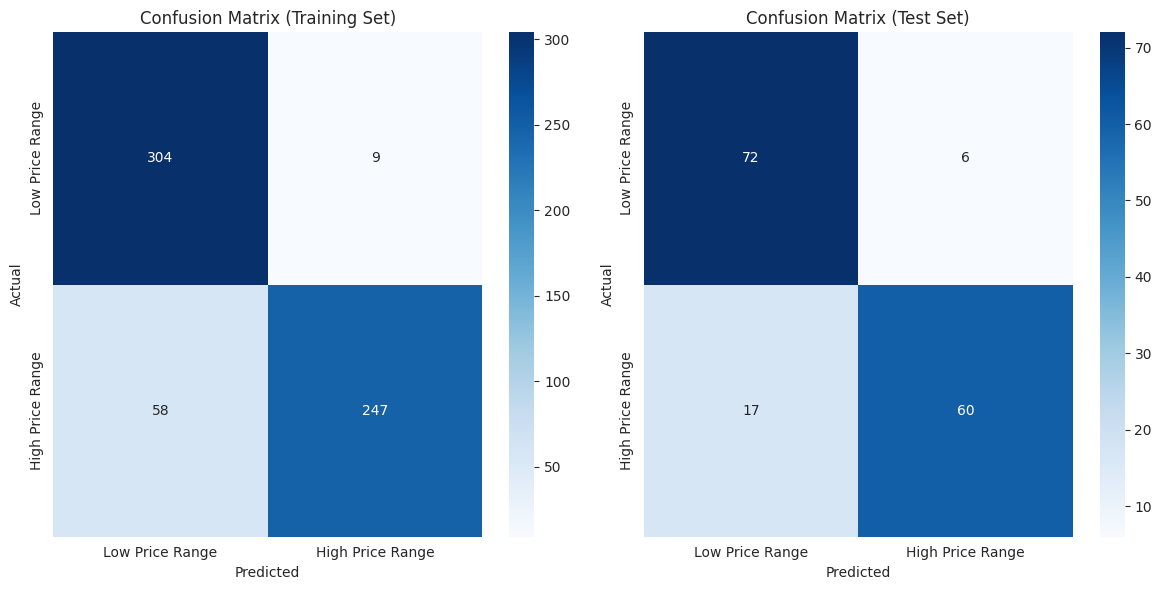


Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.84      0.97      0.90       313
           1       0.96      0.81      0.88       305

    accuracy                           0.89       618
   macro avg       0.90      0.89      0.89       618
weighted avg       0.90      0.89      0.89       618


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.81      0.92      0.86        78
           1       0.91      0.78      0.84        77

    accuracy                           0.85       155
   macro avg       0.86      0.85      0.85       155
weighted avg       0.86      0.85      0.85       155

Accuracy (Training Set): 0.8915857605177994
Accuracy (Test Set): 0.8516129032258064

Stratified Accuracy (Training Set): 0.48381877022653724
Stratified Accuracy (Test Set): 0.5612903225806452


In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier  # For stratified accuracy
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define features (X) and target (y)
X = df_storagefurniture.drop(columns=['price_category_high'])  # Drop the target variable from features
y = df_storagefurniture['price_category_high']  # Target variable

# Print the shapes of X and y
print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

# Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Initialize the DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Fit the model to the training data
model.fit(X_train, y_train)

# Class distribution in the test set
class_counts = y_test.value_counts()
total = len(y_test)
class_distribution = (class_counts / total) * 100
print("Class Distribution for 'price_category_high':\n", class_distribution)

# Predictions on training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Confusion Matrix for Training Data
train_cm = confusion_matrix(y_train, y_train_pred)
print("\nConfusion Matrix (Training Set):\n", train_cm)

# Confusion Matrix for Testing Data
test_cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix (Test Set):\n", test_cm)

# Plot Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Define custom labels
labels = ['Low Price Range', 'High Price Range']

# Training Confusion Matrix
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Confusion Matrix (Training Set)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
ax[0].set_xticklabels(labels)
ax[0].set_yticklabels(labels)

# Testing Confusion Matrix
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title("Confusion Matrix (Test Set)")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
ax[1].set_xticklabels(labels)
ax[1].set_yticklabels(labels)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

# Evaluate the model with classification reports
print("\nClassification Report (Training Set):")
print(classification_report(y_train, y_train_pred))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

print("Accuracy (Training Set):", accuracy_score(y_train, y_train_pred))
print("Accuracy (Test Set):", accuracy_score(y_test, y_test_pred))

# Step: Calculate Stratified Accuracy Using DummyClassifier
dummy_clf = DummyClassifier(strategy="stratified", random_state=42)
dummy_clf.fit(X_train, y_train)

# Stratified predictions
y_train_dummy = dummy_clf.predict(X_train)
y_test_dummy = dummy_clf.predict(X_test)

# Calculate stratified accuracy
train_stratified_accuracy = accuracy_score(y_train, y_train_dummy)
test_stratified_accuracy = accuracy_score(y_test, y_test_dummy)

# Print Stratified Accuracy
print("\nStratified Accuracy (Training Set):", train_stratified_accuracy)
print("Stratified Accuracy (Test Set):", test_stratified_accuracy)

Most Important Variables:
                                            Feature  Importance
53                      volume_category_Extra Large    0.317560
52                            volume_category_Large    0.149988
0                                  other_colors_Yes    0.091546
51                           volume_category_Medium    0.043877
10                       designer_Francis Cayouette    0.042410
29                            designer_Jon Karlsson    0.040237
2                             designer_Carina Bengs    0.031081
17                          designer_IKEA of Sweden    0.030138
48                          designer_Tord Björklund    0.025985
49           designer_Tord Björklund/IKEA of Sweden    0.024313
13                         designer_Gillis Lundgren    0.017448
9                     designer_Eva Lilja Löwenhielm    0.017006
26           designer_IKEA of Sweden/Tord Björklund    0.016666
30             designer_Jon Karlsson/IKEA of Sweden    0.016550
4             

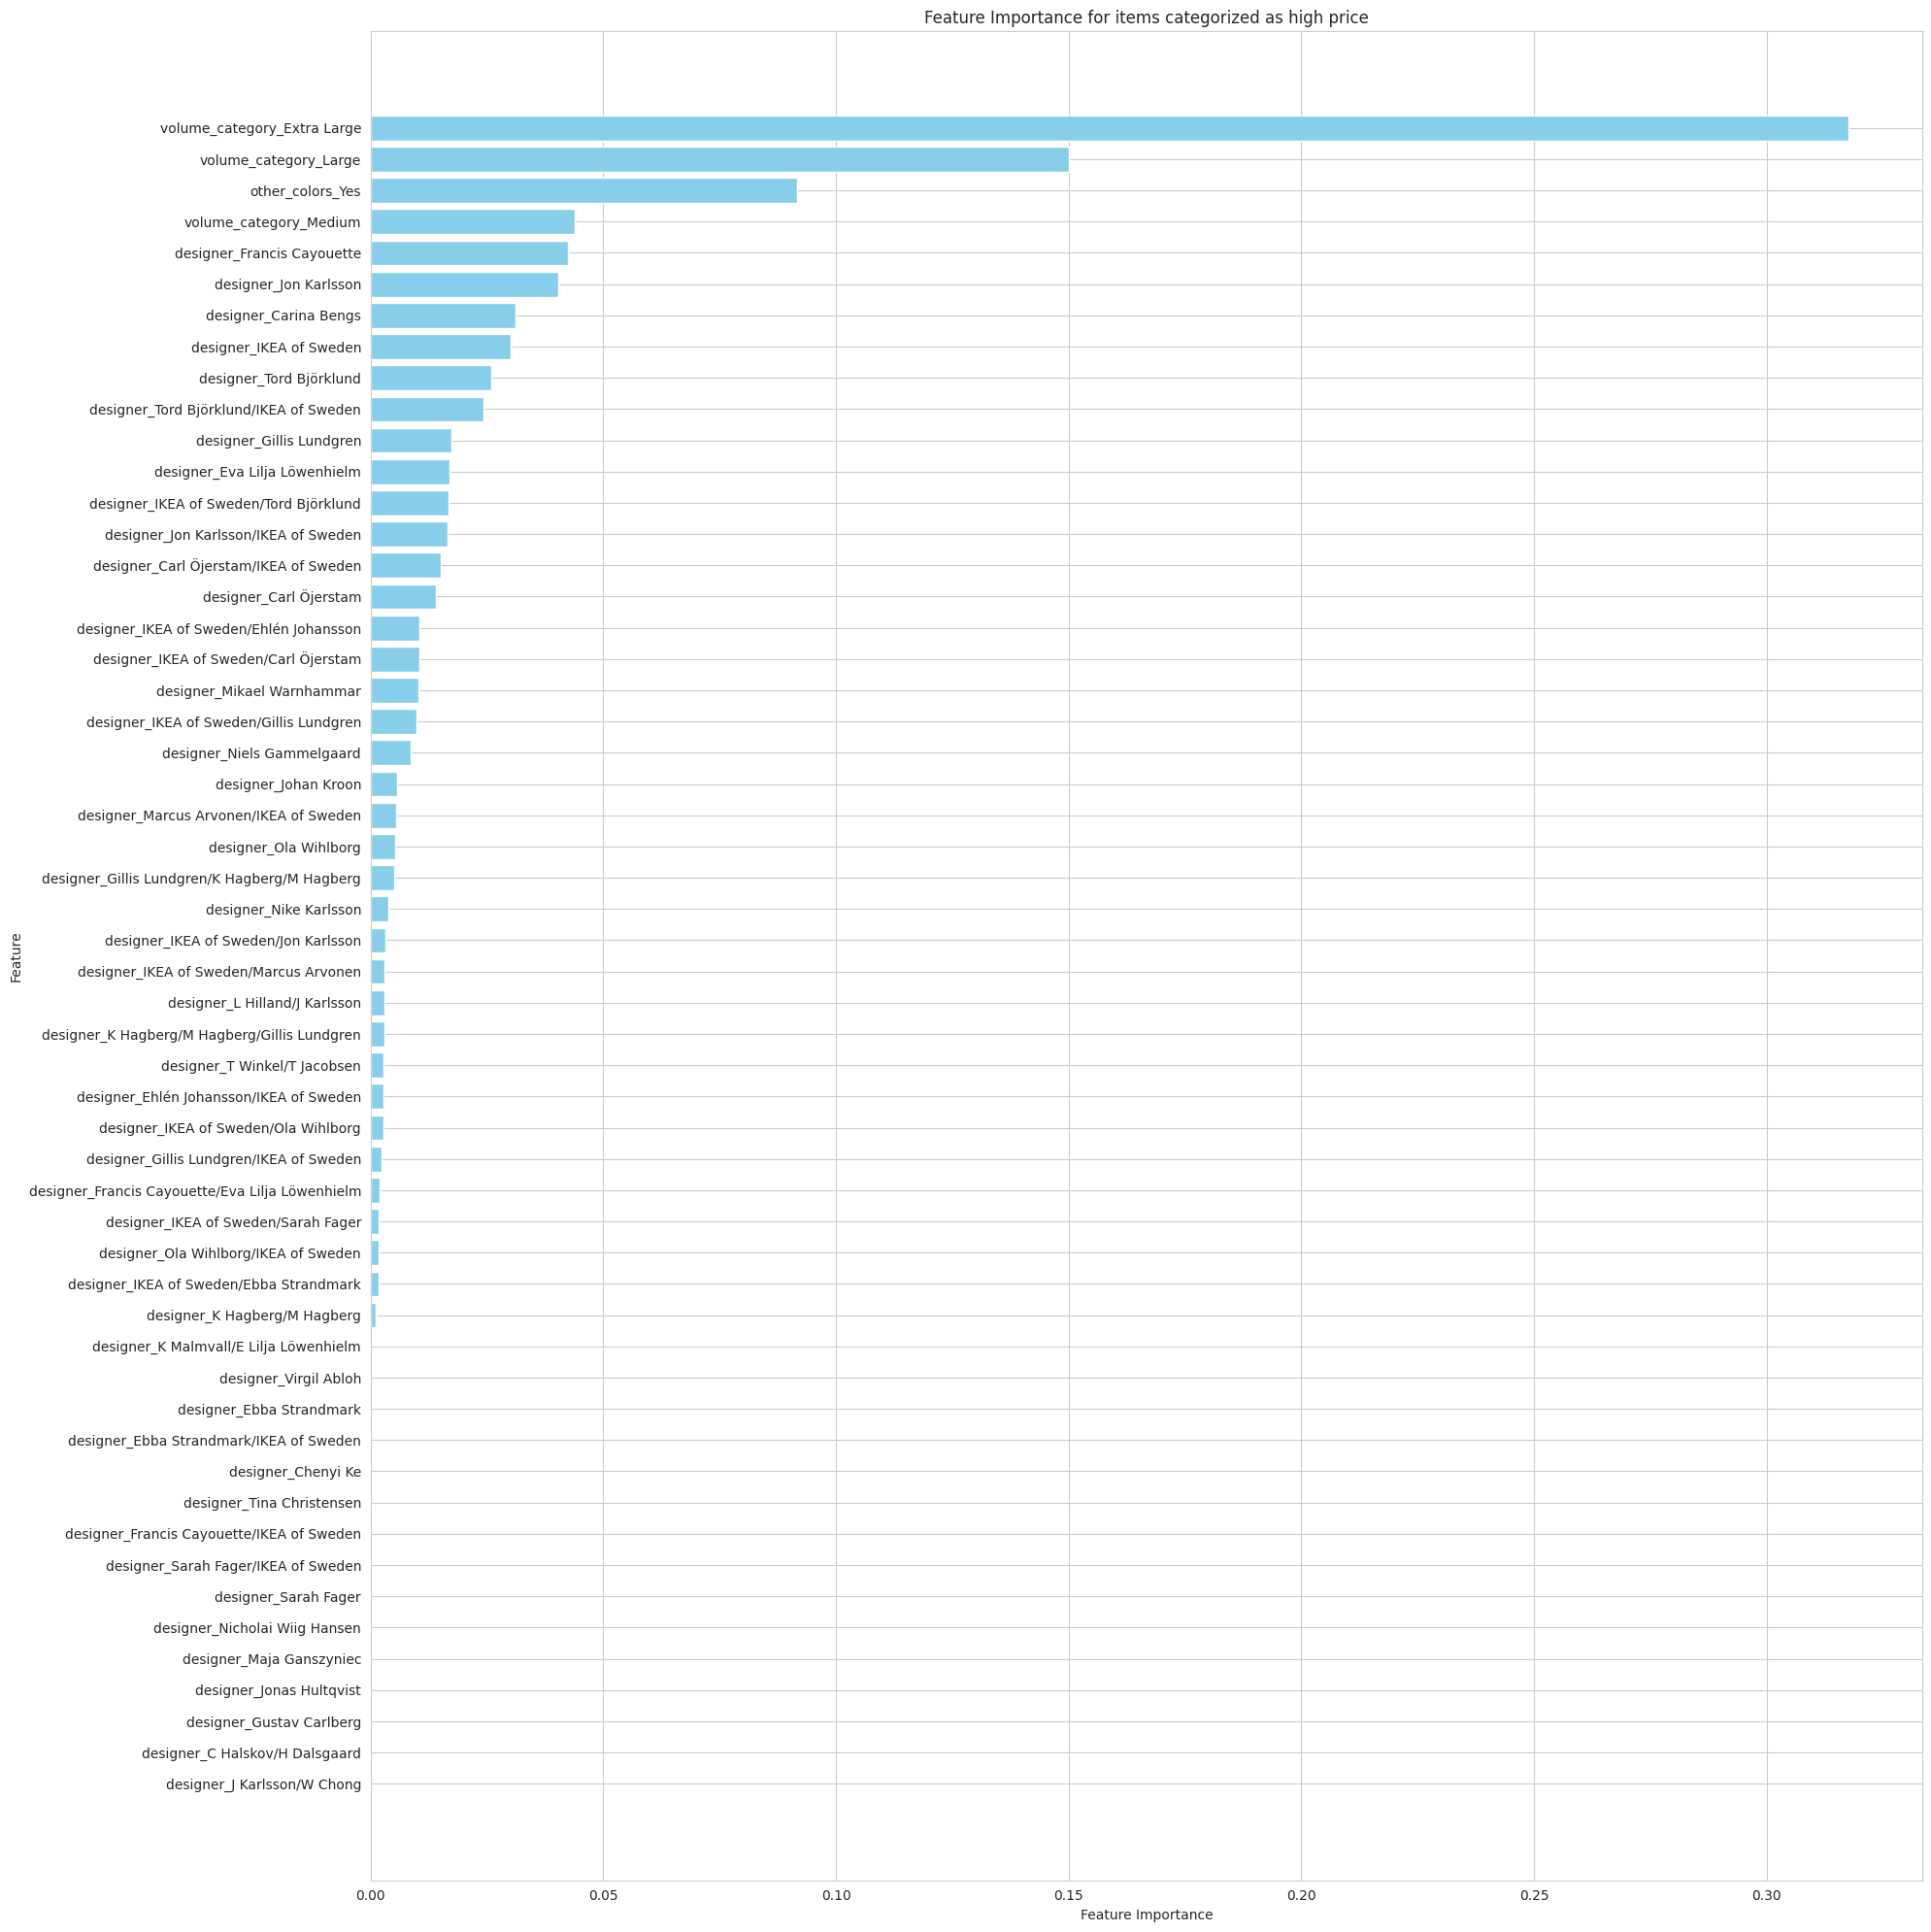

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ranking the Importance
feature_importances = model.feature_importances_  # Extract feature importance from the model
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,  # Use feature names from X_train
    'Importance': feature_importances  # Corresponding importance values
}).sort_values(by='Importance', ascending=False)  # Sort by importance

# Display the most important variables
print("Most Important Variables:")
print(feature_importance_df)

# Plot the feature importance
plt.figure(figsize=(8, 8))  # Adjust the size as needed
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for items categorized as high price")
plt.gca().invert_yaxis()  # Invert the y-axis to show the most important feature on top
plt.tight_layout()
plt.show()

In [ ]:
# Count the rows where 'designer_Francis Cayouette' equals 1
rows_with_designer = df_storagefurniture[df_storagefurniture['designer_Francis Cayouette'] == 1]

# Get the number of rows
num_rows = len(rows_with_designer)

# Print the result
print(f"Number of rows with designer_Francis Cayouette = 1: {num_rows}")

Number of rows with designer_Francis Cayouette = 1: 26


Feature importance

Top 11 Features: ['volume_category_Extra Large', 'volume_category_Large', 'other_colors_Yes', 'volume_category_Medium', 'designer_Francis Cayouette', 'designer_Jon Karlsson', 'designer_Carina Bengs', 'designer_IKEA of Sweden', 'designer_Tord Björklund', 'designer_Tord Björklund/IKEA of Sweden', 'designer_Gillis Lundgren']

Training Accuracy with Top Features: 0.8284789644012945
Testing Accuracy with Top Features: 0.8258064516129032


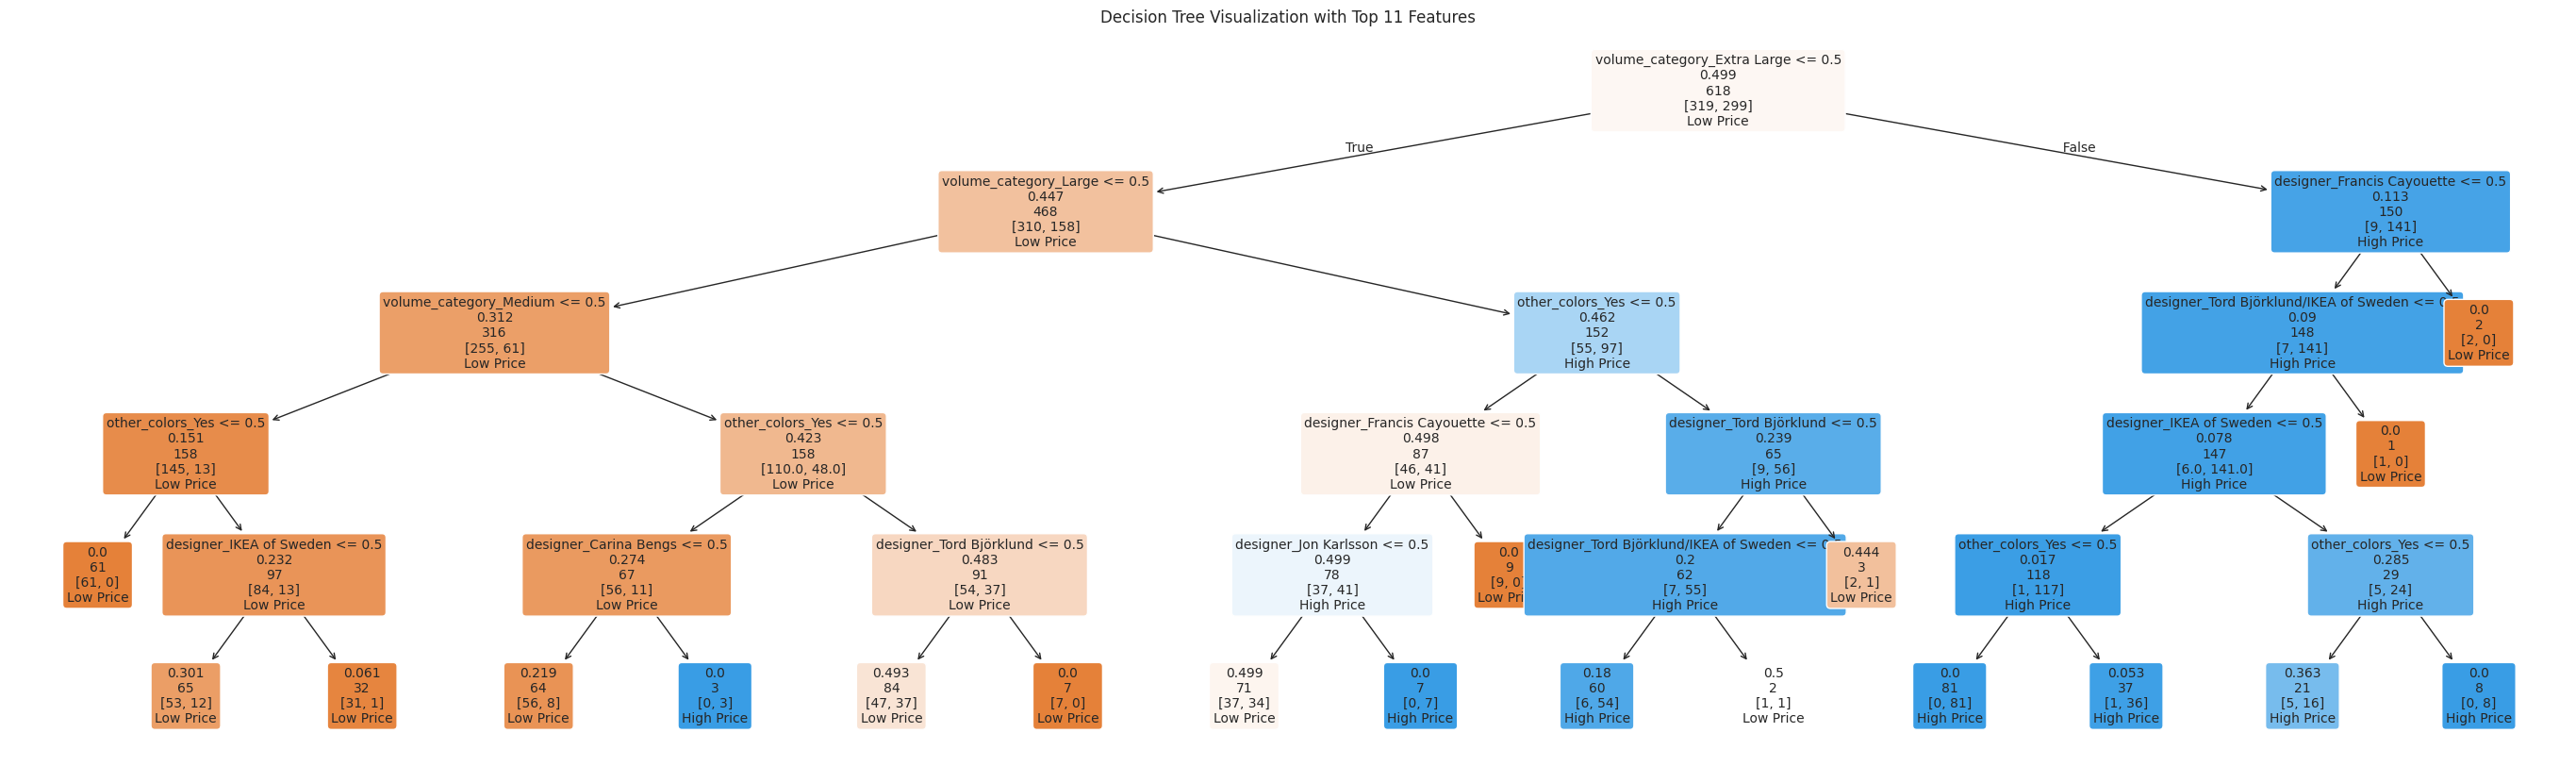

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Step 1: Select the Top 11 Features
# Assuming 'feature_importance_df' contains feature importance from a prior model
top_features = feature_importance_df['Feature'].head(11).tolist()  # Adjust to Top 11 Features
print(f"Top 11 Features: {top_features}")

# Step 2: Filter Training and Test Data for the Top Features
X_train_top = X_train[top_features]  # Select only top features for training
X_test_top = X_test[top_features]    # Select only top features for testing

# Step 3: Train a Decision Tree with the Top Features
dt_clf_top = DecisionTreeClassifier(
    criterion='gini',       # Using 'gini' for Gini Impurity
    max_depth=5,            # Limit depth to avoid overfitting
    random_state=42         # Ensure reproducibility
)
dt_clf_top.fit(X_train_top, y_train)

# Step 4: Evaluate the Model
y_train_pred_top = dt_clf_top.predict(X_train_top)
y_test_pred_top = dt_clf_top.predict(X_test_top)

# Training and Testing Accuracy
print("\nTraining Accuracy with Top Features:", accuracy_score(y_train, y_train_pred_top))
print("Testing Accuracy with Top Features:", accuracy_score(y_test, y_test_pred_top))

# Step 5: Plot the Decision Tree
plt.figure(figsize=(35, 10))
plot_tree(
    dt_clf_top,
    feature_names=top_features,     # Use the top features for visualization
    class_names=['Low Price', 'High Price'],  # Custom class names
    filled=True,
    rounded=True,
    fontsize=10,
    label='none'  # No node labels
)
plt.title("Decision Tree Visualization with Top 11 Features")
plt.show()

Applying Feature Selection to focus on the most critical features and train a new decision tree using features

Feature Importance:

volume_category_Extra Large                        0.329805
volume_category_Large                              0.151684
other_colors_Yes                                   0.090148
designer_Jon Karlsson                              0.042669
volume_category_Medium                             0.040731
designer_Carina Bengs                              0.029608
designer_Francis Cayouette                         0.027624
designer_IKEA of Sweden                            0.026623
designer_Tord Björklund                            0.026077
designer_Eva Lilja Löwenhielm                      0.024481
designer_Gillis Lundgren                           0.019104
designer_Tord Björklund/IKEA of Sweden             0.017634
designer_IKEA of Sweden/Tord Björklund             0.017634
designer_Mikael Warnhammar                         0.015402
designer_Carl Öjerstam                             0.012868
designer_L Hilland/J Karlsson                      0.012605
designer_Carl Öjers

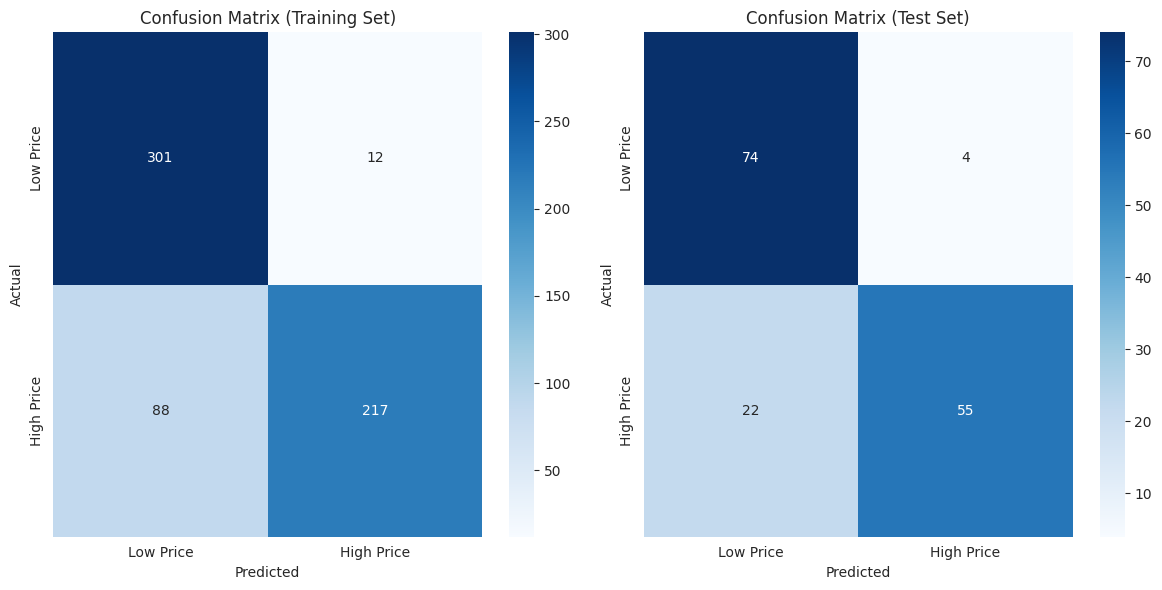


Training Accuracy: 0.8381877022653722
Testing Accuracy: 0.832258064516129

Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.77      0.96      0.86       313
           1       0.95      0.71      0.81       305

    accuracy                           0.84       618
   macro avg       0.86      0.84      0.84       618
weighted avg       0.86      0.84      0.84       618


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.77      0.95      0.85        78
           1       0.93      0.71      0.81        77

    accuracy                           0.83       155
   macro avg       0.85      0.83      0.83       155
weighted avg       0.85      0.83      0.83       155


Stratified Accuracy (Training Set): 0.48381877022653724
Stratified Accuracy (Test Set): 0.5612903225806452


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier  # For stratified accuracy
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Define Features (X) and Target (y)
X = df_storagefurniture.drop(columns=['price_category_high'])  # Features
y = df_storagefurniture['price_category_high']  # Target variable

# Step 2: Train an Initial Decision Tree
initial_tree = DecisionTreeClassifier(criterion='entropy', random_state=42)
initial_tree.fit(X, y)

# Step 3: Calculate Feature Importance
feature_importances = pd.Series(initial_tree.feature_importances_, index=X.columns).sort_values(ascending=False)

# Display the most important features
print("Feature Importance:\n")
print(feature_importances)

# Select the top 10 most important features
top_features = feature_importances.head(10).index.tolist()
print("\nTop Features Selected for the Decision Tree:\n", top_features)

# Step 4: Filter Training Data with Top Features
X_top = X[top_features]

# Step 5: Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_top, y, test_size=0.20, random_state=42, stratify=y)

# Step 6: Train a New Decision Tree Using Top Features
model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Step 7: Make Predictions for Training and Testing Sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Step 8: Confusion Matrix for Training Data
train_cm = confusion_matrix(y_train, y_train_pred)

# Confusion Matrix for Testing Data
test_cm = confusion_matrix(y_test, y_test_pred)

# Plot Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

labels = ['Low Price', 'High Price']

# Training Confusion Matrix
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Confusion Matrix (Training Set)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
ax[0].set_xticklabels(labels)
ax[0].set_yticklabels(labels)

# Testing Confusion Matrix
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title("Confusion Matrix (Test Set)")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
ax[1].set_xticklabels(labels)
ax[1].set_yticklabels(labels)

plt.tight_layout()
plt.show()

# Step 9: Evaluate the Model
print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report (Training Set):")
print(classification_report(y_train, y_train_pred))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# Step 10: Calculate Stratified Accuracy Using DummyClassifier
dummy_clf = DummyClassifier(strategy="stratified", random_state=42)
dummy_clf.fit(X_train, y_train)

# Stratified predictions
y_train_dummy = dummy_clf.predict(X_train)
y_test_dummy = dummy_clf.predict(X_test)

# Calculate stratified accuracy
train_stratified_accuracy = accuracy_score(y_train, y_train_dummy)
test_stratified_accuracy = accuracy_score(y_test, y_test_dummy)

# Print Stratified Accuracy
print("\nStratified Accuracy (Training Set):", train_stratified_accuracy)
print("Stratified Accuracy (Test Set):", test_stratified_accuracy)

applying SMOTE to try and improve model

Shape of X (features): (773, 54)
Shape of y (target): (773,)

Class Distribution After SMOTE:
price_category_high
0    313
1    313
Name: count, dtype: int64

Confusion Matrix (Training Set):
 [[305   8]
 [ 89 224]]

Confusion Matrix (Test Set):
 [[72  6]
 [22 55]]


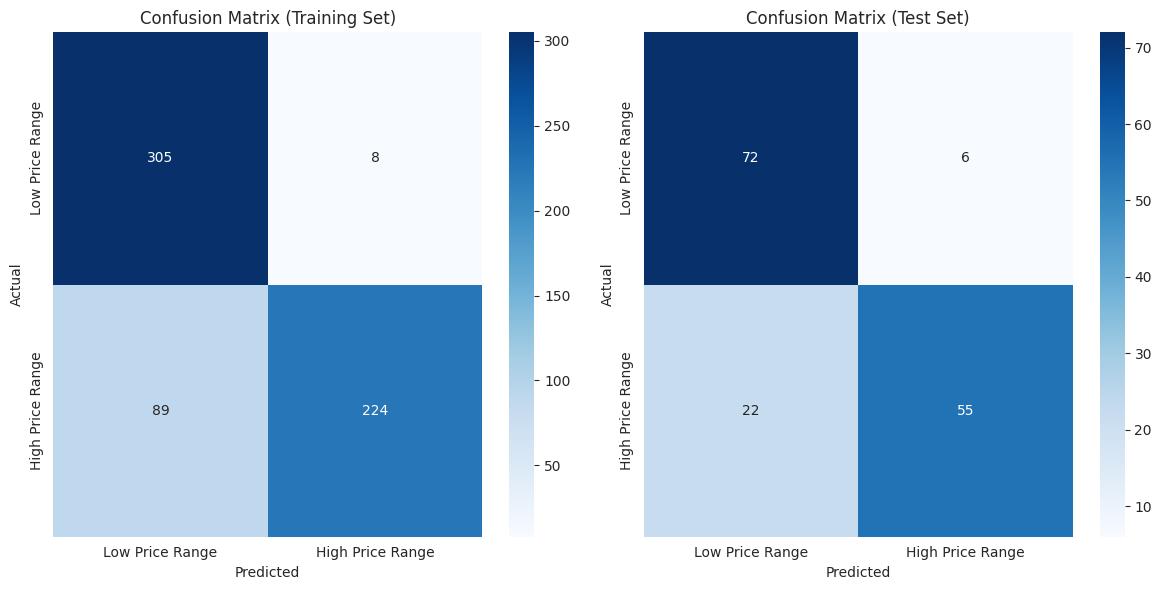


Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.77      0.97      0.86       313
           1       0.97      0.72      0.82       313

    accuracy                           0.85       626
   macro avg       0.87      0.85      0.84       626
weighted avg       0.87      0.85      0.84       626


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.77      0.92      0.84        78
           1       0.90      0.71      0.80        77

    accuracy                           0.82       155
   macro avg       0.83      0.82      0.82       155
weighted avg       0.83      0.82      0.82       155

Accuracy (Training Set): 0.8450479233226837
Accuracy (Test Set): 0.8193548387096774

Stratified Accuracy (Training Set): 0.48381877022653724
Stratified Accuracy (Test Set): 0.5612903225806452


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.dummy import DummyClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Define features (X) and target (y)
X = df_storagefurniture.drop(columns=['price_category_high'])  # Drop the target variable from features
y = df_storagefurniture['price_category_high']  # Target variable

# Ensure all columns are numeric (SMOTE requires numeric data)
X = X.astype(int)

# Print the shapes of X and y
print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

# Step 2: Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Step 3: Apply SMOTE to the training data
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

# Print class distribution after SMOTE
print("\nClass Distribution After SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

# Step 4: Initialize the DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

# Fit the model to the resampled training data
model.fit(X_train_resampled, y_train_resampled)

# Step 5: Predictions on training and testing sets
y_train_pred = model.predict(X_train_resampled)
y_test_pred = model.predict(X_test)

# Step 6: Confusion Matrix for Training Data
train_cm = confusion_matrix(y_train_resampled, y_train_pred)
print("\nConfusion Matrix (Training Set):\n", train_cm)

# Confusion Matrix for Testing Data
test_cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix (Test Set):\n", test_cm)

# Step 7: Plot Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Define custom labels
labels = ['Low Price Range', 'High Price Range']

# Training Confusion Matrix
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Confusion Matrix (Training Set)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
ax[0].set_xticklabels(labels)
ax[0].set_yticklabels(labels)

# Testing Confusion Matrix
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title("Confusion Matrix (Test Set)")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
ax[1].set_xticklabels(labels)
ax[1].set_yticklabels(labels)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

# Step 8: Evaluate the model with classification reports
print("\nClassification Report (Training Set):")
print(classification_report(y_train_resampled, y_train_pred))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# Accuracy Scores
train_accuracy = accuracy_score(y_train_resampled, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Accuracy (Training Set):", train_accuracy)
print("Accuracy (Test Set):", test_accuracy)

# Step 9: Calculate Stratified Accuracy Using DummyClassifier
dummy_clf = DummyClassifier(strategy="stratified", random_state=42)
dummy_clf.fit(X_train, y_train)

# Stratified predictions
y_train_dummy = dummy_clf.predict(X_train)
y_test_dummy = dummy_clf.predict(X_test)

# Calculate stratified accuracy
train_stratified_accuracy = accuracy_score(y_train, y_train_dummy)
test_stratified_accuracy = accuracy_score(y_test, y_test_dummy)

# Print Stratified Accuracy
print("\nStratified Accuracy (Training Set):", train_stratified_accuracy)
print("Stratified Accuracy (Test Set):", test_stratified_accuracy)

ensemble method : Combining multiple decision trees

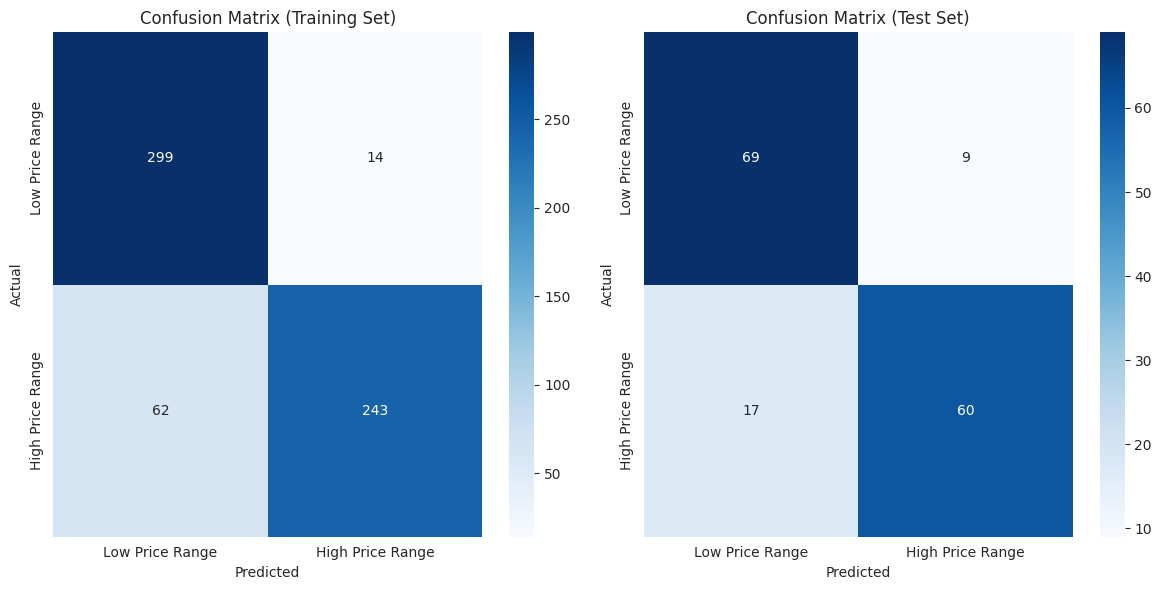


Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.83      0.96      0.89       313
           1       0.95      0.80      0.86       305

    accuracy                           0.88       618
   macro avg       0.89      0.88      0.88       618
weighted avg       0.89      0.88      0.88       618


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        78
           1       0.87      0.78      0.82        77

    accuracy                           0.83       155
   macro avg       0.84      0.83      0.83       155
weighted avg       0.84      0.83      0.83       155

Accuracy (Training Set): 0.8770226537216829
Accuracy (Test Set): 0.832258064516129

Stratified Accuracy (Training Set): 0.48381877022653724
Stratified Accuracy (Test Set): 0.5612903225806452


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.dummy import DummyClassifier  # Import DummyClassifier for stratified accuracy
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define Features (X) and Target (y)
X = df_storagefurniture.drop(columns=['price_category_high'])  # Features
y = df_storagefurniture['price_category_high']  # Target variable

# Ensure all columns are numeric
X = X.astype(int)

# Step 2: Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Step 3: Initialize and Train the Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,  # Number of trees
    max_depth=10,      # Maximum depth of trees
    random_state=42    # Ensures reproducibility
)
rf_model.fit(X_train, y_train)

# Step 4: Predictions on Training and Testing Sets
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Step 5: Evaluate the Model with Confusion Matrices
train_cm = confusion_matrix(y_train, y_train_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Plot Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
labels = ['Low Price Range', 'High Price Range']

# Training Confusion Matrix
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Confusion Matrix (Training Set)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
ax[0].set_xticklabels(labels)
ax[0].set_yticklabels(labels)

# Testing Confusion Matrix
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title("Confusion Matrix (Test Set)")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
ax[1].set_xticklabels(labels)
ax[1].set_yticklabels(labels)

plt.tight_layout()
plt.show()

# Step 6: Evaluate the Model with Classification Reports
print("\nClassification Report (Training Set):")
print(classification_report(y_train, y_train_pred))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# Step 7: Print Accuracy Scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Accuracy (Training Set):", train_accuracy)
print("Accuracy (Test Set):", test_accuracy)

# Step 8: Calculate Stratified Accuracy Using DummyClassifier
dummy_clf = DummyClassifier(strategy="stratified", random_state=42)
dummy_clf.fit(X_train, y_train)

# Stratified predictions
y_train_dummy = dummy_clf.predict(X_train)
y_test_dummy = dummy_clf.predict(X_test)

# Calculate stratified accuracy
train_stratified_accuracy = accuracy_score(y_train, y_train_dummy)
test_stratified_accuracy = accuracy_score(y_test, y_test_dummy)

# Print Stratified Accuracy
print("\nStratified Accuracy (Training Set):", train_stratified_accuracy)
print("Stratified Accuracy (Test Set):", test_stratified_accuracy)

In [ ]:
print("Class Distribution in Training Set:")
print(y_train.value_counts(normalize=True))
print("Class Distribution in Testing Set:")
print(y_test.value_counts(normalize=True))

Class Distribution in Training Set:
price_category_high
0    0.506472
1    0.493528
Name: proportion, dtype: float64
Class Distribution in Testing Set:
price_category_high
0    0.503226
1    0.496774
Name: proportion, dtype: float64




### **Random Forest Model**

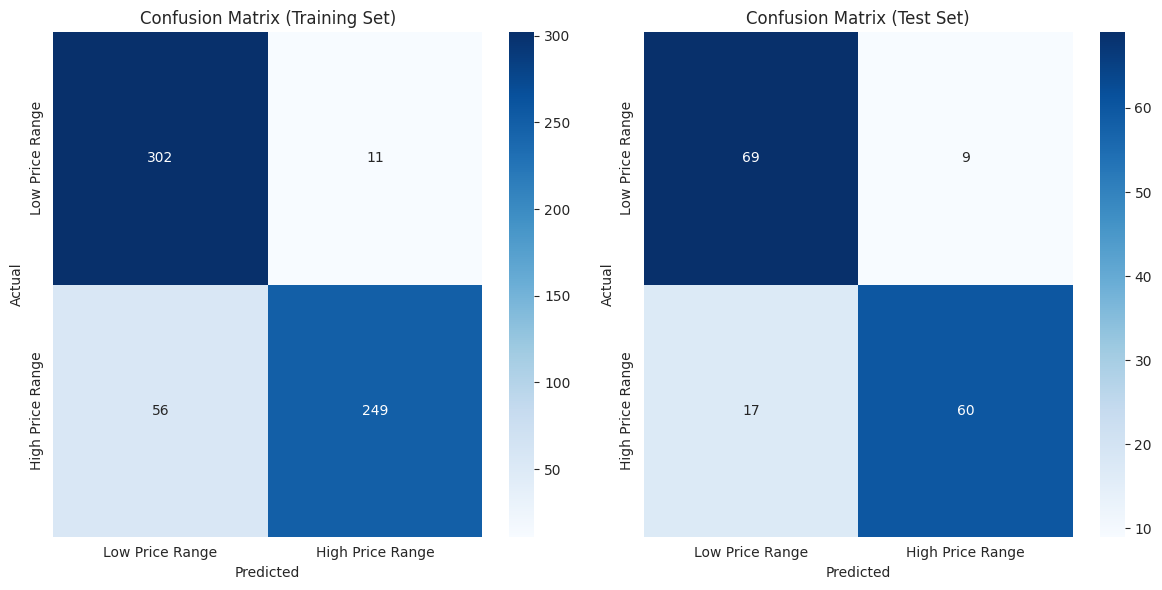


Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.84      0.96      0.90       313
           1       0.96      0.82      0.88       305

    accuracy                           0.89       618
   macro avg       0.90      0.89      0.89       618
weighted avg       0.90      0.89      0.89       618


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        78
           1       0.87      0.78      0.82        77

    accuracy                           0.83       155
   macro avg       0.84      0.83      0.83       155
weighted avg       0.84      0.83      0.83       155

Accuracy (Training Set): 0.8915857605177994
Accuracy (Test Set): 0.832258064516129


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define Features (X) and Target (y)
X = df_storagefurniture.drop(columns=['price_category_high'])  # Features
y = df_storagefurniture['price_category_high']  # Target variable

# Ensure all columns are numeric (if necessary)
X = X.astype(int)

# Step 2: Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Step 3: Initialize and Train the Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,  # Number of trees
    max_depth=None,    # Default: grow trees until all leaves are pure or have less than min_samples_split samples
    random_state=42    # Ensures reproducibility
)
rf_model.fit(X_train, y_train)

# Step 4: Make Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Step 5: Confusion Matrices
train_cm = confusion_matrix(y_train, y_train_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Plot Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
labels = ['Low Price Range', 'High Price Range']

# Training Confusion Matrix
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Confusion Matrix (Training Set)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
ax[0].set_xticklabels(labels)
ax[0].set_yticklabels(labels)

# Testing Confusion Matrix
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title("Confusion Matrix (Test Set)")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
ax[1].set_xticklabels(labels)
ax[1].set_yticklabels(labels)

plt.tight_layout()
plt.show()

# Step 6: Evaluate the Model
print("\nClassification Report (Training Set):")
print(classification_report(y_train, y_train_pred))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

print("Accuracy (Training Set):", accuracy_score(y_train, y_train_pred))
print("Accuracy (Test Set):", accuracy_score(y_test, y_test_pred))


Top 10 Most Important Features:
                                     Feature  Importance
3               volume_category_Extra Large    0.279379
2                     volume_category_Large    0.127831
0                          other_colors_Yes    0.070445
23  designer_IKEA of Sweden/Ehlén Johansson    0.055745
1                    volume_category_Medium    0.052134
11  designer_Ehlén Johansson/IKEA of Sweden    0.045911
32                    designer_Jon Karlsson    0.038292
13               designer_Francis Cayouette    0.033063
5                     designer_Carina Bengs    0.030530
20                  designer_IKEA of Sweden    0.028943


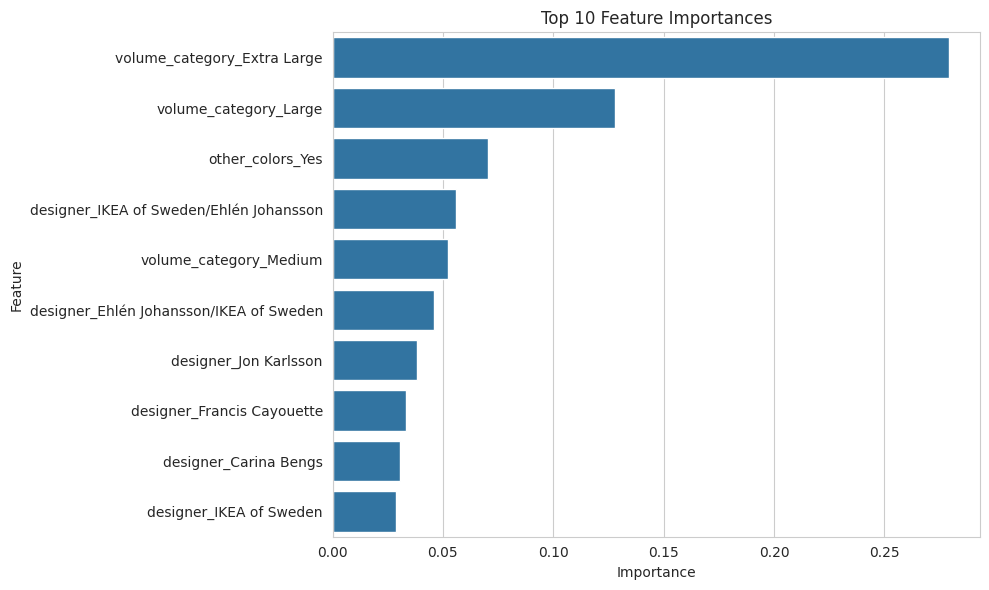

In [ ]:
# Step 7: Feature Importances
import pandas as pd

# Extract feature importances
feature_importances = rf_model.feature_importances_

# Combine feature names and their importances into a DataFrame
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Select top 10 features
top_10_features = importance_df.head(10)

# Display the top 10 features
print("\nTop 10 Most Important Features:\n", top_10_features)

# Step 8: Visualize the Top 10 Features
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features['Importance'], y=top_10_features['Feature'])
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

apply smote


Class Distribution After SMOTE:
price_category_high
0    313
1    313
Name: count, dtype: int64


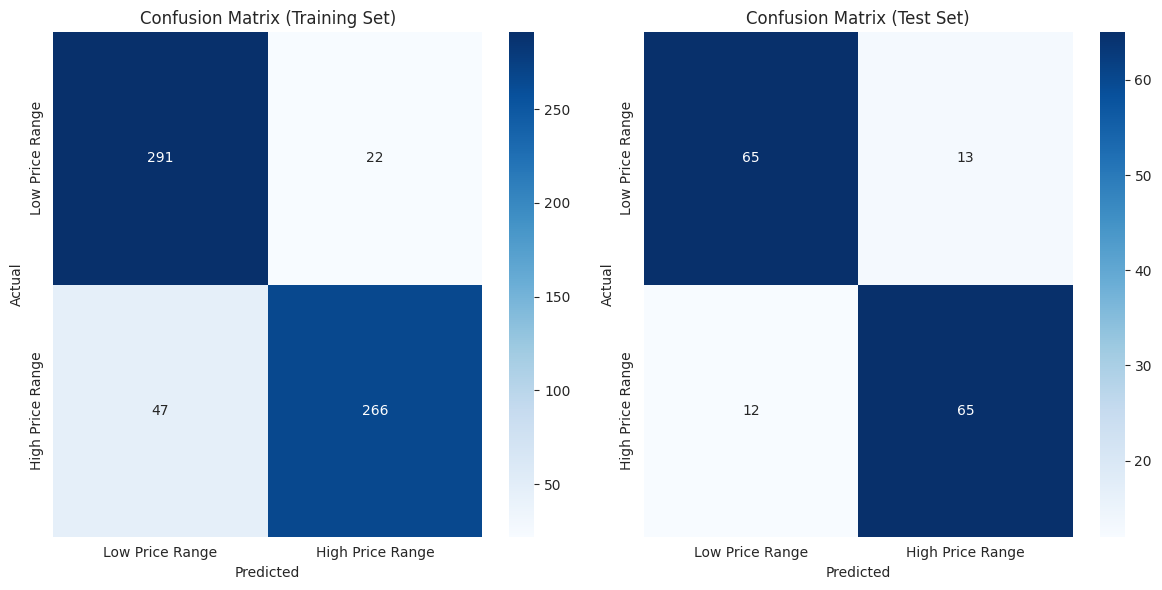


Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       313
           1       0.92      0.85      0.89       313

    accuracy                           0.89       626
   macro avg       0.89      0.89      0.89       626
weighted avg       0.89      0.89      0.89       626


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.84      0.83      0.84        78
           1       0.83      0.84      0.84        77

    accuracy                           0.84       155
   macro avg       0.84      0.84      0.84       155
weighted avg       0.84      0.84      0.84       155

Accuracy (Training Set): 0.889776357827476
Accuracy (Test Set): 0.8387096774193549


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define Features (X) and Target (y)
X = df_storagefurniture.drop(columns=['price_category_high'])  # Features
y = df_storagefurniture['price_category_high']  # Target variable

# Ensure all columns are numeric (if necessary)
X = X.astype(int)

# Step 2: Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Step 3: Apply SMOTE to the Training Data
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

# Print Class Distribution After SMOTE
print("\nClass Distribution After SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

# Step 4: Initialize and Train the Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,  # Number of trees
    max_depth=None,    # Default: grow trees until all leaves are pure
    random_state=42    # Ensures reproducibility
)
rf_model.fit(X_train_resampled, y_train_resampled)

# Step 5: Make Predictions
y_train_pred = rf_model.predict(X_train_resampled)
y_test_pred = rf_model.predict(X_test)

# Step 6: Confusion Matrices
train_cm = confusion_matrix(y_train_resampled, y_train_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Plot Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
labels = ['Low Price Range', 'High Price Range']

# Training Confusion Matrix
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Confusion Matrix (Training Set)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
ax[0].set_xticklabels(labels)
ax[0].set_yticklabels(labels)

# Testing Confusion Matrix
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title("Confusion Matrix (Test Set)")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
ax[1].set_xticklabels(labels)
ax[1].set_yticklabels(labels)

plt.tight_layout()
plt.show()

# Step 7: Evaluate the Model
print("\nClassification Report (Training Set):")
print(classification_report(y_train_resampled, y_train_pred))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

print("Accuracy (Training Set):", accuracy_score(y_train_resampled, y_train_pred))
print("Accuracy (Test Set):", accuracy_score(y_test, y_test_pred))

Hypermater tuning :RandomizedSearch to find the best values

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import numpy as np

# Define the parameter distributions
param_distributions = {
    'n_estimators': randint(50, 500),  # Number of trees between 50 and 500
    'max_depth': [None] + list(range(5, 51, 5)),  # Depth from 5 to 50 or None
    'min_samples_split': randint(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': randint(1, 20),   # Minimum samples at a leaf node
    'max_features': uniform(0.1, 0.9)    # Fraction of features to consider at each split
}

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings to sample
    scoring='accuracy',
    cv=5,       # 5-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1   # Use all available processors
)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train_resampled, y_train_resampled)

# Best parameters and score
print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'max_depth': 25, 'max_features': 0.1007008892569129, 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 363}
Best Accuracy: 0.8259301587301587


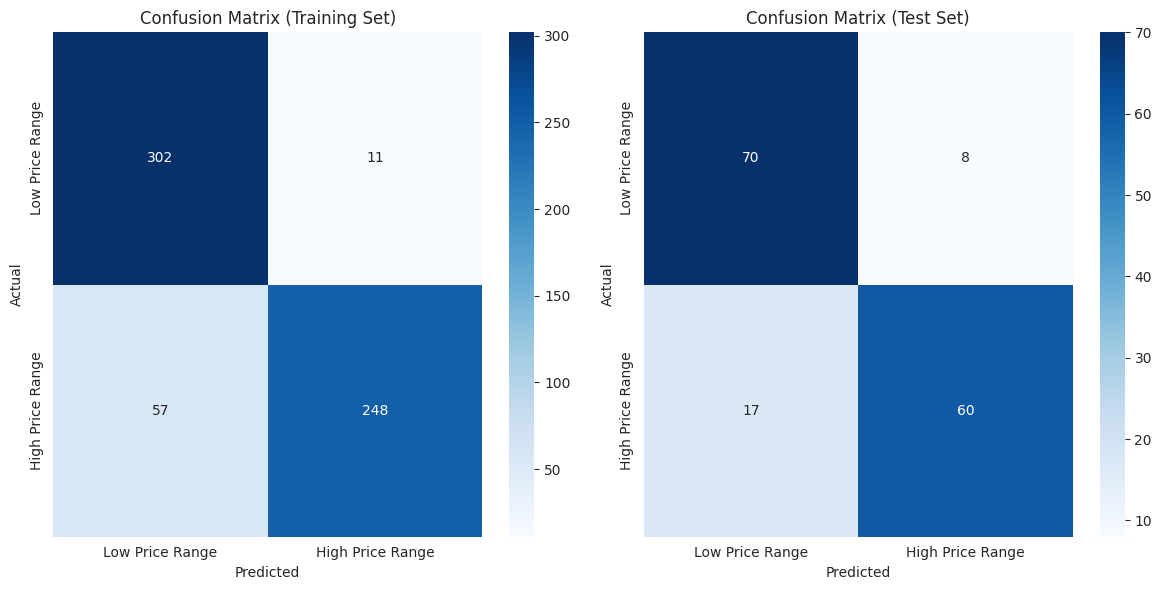


Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.84      0.96      0.90       313
           1       0.96      0.81      0.88       305

    accuracy                           0.89       618
   macro avg       0.90      0.89      0.89       618
weighted avg       0.90      0.89      0.89       618


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.80      0.90      0.85        78
           1       0.88      0.78      0.83        77

    accuracy                           0.84       155
   macro avg       0.84      0.84      0.84       155
weighted avg       0.84      0.84      0.84       155

Accuracy (Training Set): 0.889967637540453
Accuracy (Test Set): 0.8387096774193549


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define Features (X) and Target (y)
X = df_storagefurniture.drop(columns=['price_category_high'])  # Features
y = df_storagefurniture['price_category_high']  # Target variable

# Ensure all columns are numeric
X = X.astype(int)

# Step 2: Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y  # Stratify to maintain class distribution
)

# Step 3: Initialize the Random Forest Classifier with best parameters
rf_model = RandomForestClassifier(
    n_estimators=363,        # Number of trees
    max_depth=25,            # Maximum depth of trees
    max_features=0.1007008892569129,  # Fraction of features to consider
    min_samples_split=13,    # Minimum samples required to split a node
    min_samples_leaf=1,      # Minimum samples required at each leaf
    random_state=42          # Ensures reproducibility
)

# Step 4: Train the Random Forest Model
rf_model.fit(X_train, y_train)

# Step 5: Make Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Step 6: Confusion Matrices
train_cm = confusion_matrix(y_train, y_train_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Plot Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
labels = ['Low Price Range', 'High Price Range']

# Training Confusion Matrix
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Confusion Matrix (Training Set)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
ax[0].set_xticklabels(labels)
ax[0].set_yticklabels(labels)

# Testing Confusion Matrix
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title("Confusion Matrix (Test Set)")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
ax[1].set_xticklabels(labels)
ax[1].set_yticklabels(labels)

plt.tight_layout()
plt.show()

# Step 7: Evaluate the Model
print("\nClassification Report (Training Set):")
print(classification_report(y_train, y_train_pred))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

print("Accuracy (Training Set):", accuracy_score(y_train, y_train_pred))
print("Accuracy (Test Set):", accuracy_score(y_test, y_test_pred))

Precision for high range increased, even though not much change in accuracy for training and testing.

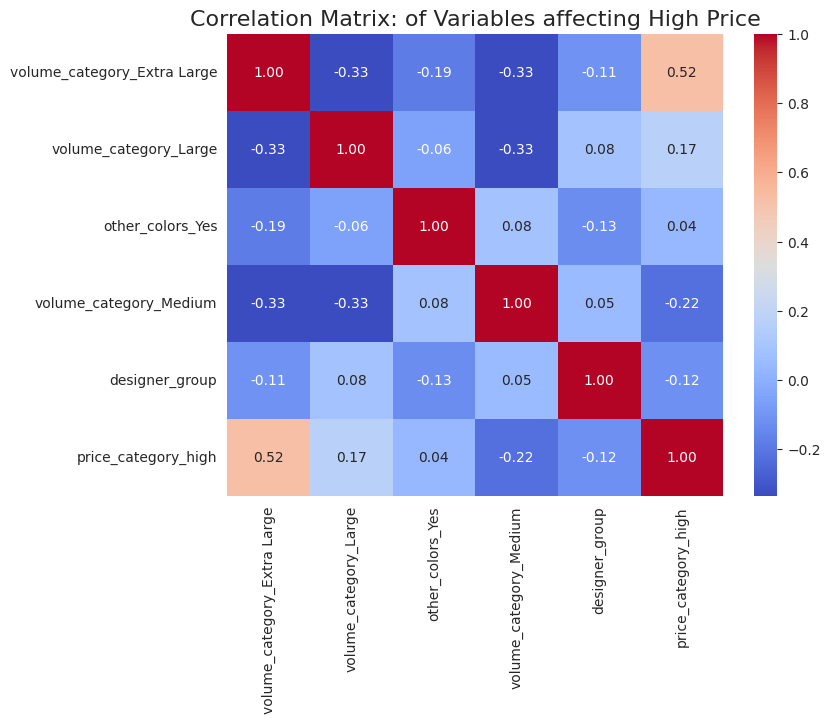

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Group all designers into one category
# Assuming designer-related columns start with 'designer_'
df_storagefurniture['designer_group'] = df_storagefurniture.filter(like='designer_').any(axis=1).astype(int)

# Step 2: Define selected columns, including grouped designers
selected_columns = [
    'volume_category_Extra Large',
    'volume_category_Large',
    'other_colors_Yes',
    'volume_category_Medium',
    'designer_group',            # Grouped designer column
    'price_category_high'        # Target variable
]

# Step 3: Check if all selected columns exist
missing_columns = [col for col in selected_columns if col not in df_storagefurniture.columns]
if missing_columns:
    print(f"Missing columns: {missing_columns}")
else:
    # Step 4: Select only the relevant columns
    df_selected = df_storagefurniture[selected_columns]

    # Step 5: Compute the correlation matrix
    correlation_matrix = df_selected.corr()

    # Step 6: Plot the correlation matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)

    # Add title
    plt.title("Correlation Matrix: of Variables affecting High Price", fontsize=16)
    plt.show()